# Project Exploratory Data Analysis

## Project Overview
**Goal**: Predict `ADHD_Outcome` (0/1) and `Sex_F` (0/1) using fMRI connectivity, demographics, and behavioral data.
**Data Source**: Kaggle WiDS Datathon 2025

## Notebook Structure:
1. **Setup**: Library imports and visualization style.
2. **Data Loading (Cleaned)**: Loading the pre-processed/cleaned dataset.
3. **Missing Value Analysis (Raw)**: Analyzing initial data quality.
4. **Target Analysis**: Distribution of ADHD and Sex.
5. **Feature EDA**: Demographics, Quantitative features.
6. **Functional Connectivity**: fMRI analysis.

## 1. Imports & Visualization Setup
Setting up the environment and loading libraries.

In [ ]:
import os
import sys

# ------------------------------------------------------------------------------
# Setup for Colab (Install dependencies first)
# ------------------------------------------------------------------------------
if 'google.colab' in sys.modules:
    print("Detected Google Colab environment. Installing missingno...")
    !pip install -q missingno

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

# Preprocessing & Analysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional: Missing values visualization
try:
    import missingno as msno
except ImportError:
    # If import fails, try installing it again (fallback) and re-importing
    if 'google.colab' in sys.modules:
        print("Import failed. Trying to force install missingno again...")
        !pip install missingno
        import missingno as msno
    else:
        print("missingno not found, skipping specific plots.")

# ------------------------------------------------------------------------------
# Visualization Style Settings
# ------------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
PALETTE = "viridis"
sns.set_palette(PALETTE)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries imported and style set.")

Detected Google Colab environment. Installing missingno...
Libraries imported and style set.


## 2. Data Loading: Cleaned Data
Loading the pre-processed dataset for analysis.

In [ ]:
# ------------------------------------------------------------------------------
# Path Setup
# ------------------------------------------------------------------------------
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    # UPDATE THIS PATH FOR COLAB
    BASE_DIR = "/content/drive/MyDrive/cleaned_data"
    RAW_DIR = "/content/drive/MyDrive/widsdatathon2025"
else:
    # Local Path
    BASE_DIR = r"F:\0Master\project\EDA\cleaned_data"
    RAW_DIR = r"F:\0Master\project\EDA\widsdatathon2025"

# ------------------------------------------------------------------------------
# Load CLEANED Data
# ------------------------------------------------------------------------------
print("Loading Cleaned Data for EDA...")

df_clean = None

# Try to find split files in 'cleaned_data/Train' or nested 'cleaned_data/cleaned_data'
# Note: On Colab (Linux), paths are case-sensitive. We search for 'Train' or 'train'.
# STRICTLY LIMIT to TRAIN folder as requested
train_dir_candidates = [
    os.path.join(BASE_DIR, "Train"),
    os.path.join(BASE_DIR, "train"),
    os.path.join(BASE_DIR, "cleaned_data")
]
train_dir = next((d for d in train_dir_candidates if os.path.exists(d)), None)

cleaned_files = []
if train_dir:
    cleaned_files = glob.glob(os.path.join(train_dir, "cleaned_train_*.csv"))
    # Exclude One-Hot Encoded files to avoid duplicates and confusion
    cleaned_files = [f for f in cleaned_files if 'ohe' not in f.lower()]
    print(f"Searching in Train directory: {train_dir}")
else:
    # Fallback: search in BASE_DIR directly if flattened, but filter for 'train' in filename
    print("Train directory not found, searching in BASE_DIR for 'cleaned_train_*.csv'")
    cleaned_files = glob.glob(os.path.join(BASE_DIR, "cleaned_train_*.csv"))

# Locate TRAINING_SOLUTIONS.xlsx (Target Labels)
solutions_path = os.path.join(BASE_DIR, "TRAINING_SOLUTIONS.xlsx")
if os.path.exists(solutions_path):
    cleaned_files.append(solutions_path)
else:
    # Try finding it in the nested cleaned_data folder
    nested_solutions = os.path.join(BASE_DIR, "cleaned_data", "TRAINING_SOLUTIONS.xlsx")
    if os.path.exists(nested_solutions):
        cleaned_files.append(nested_solutions)
    else:
        # Try finding it in the Raw Data folder (TRAIN_NEW)
        raw_solutions = os.path.join(RAW_DIR, "TRAIN_NEW", "TRAINING_SOLUTIONS.xlsx")
        if os.path.exists(raw_solutions):
            print(f"Found Training Solutions in Raw Dir: {raw_solutions}")
            cleaned_files.append(raw_solutions)
        else:
            print("Warning: TRAINING_SOLUTIONS.xlsx not found in cleaned or raw directories. Target variables may be missing.")

print(f"Found {len(cleaned_files)} files to merge.")

dfs_to_merge = []
for fpath in cleaned_files:
    fname = os.path.basename(fpath)
    print(f"Reading: {fname} ...", end=" ")
    try:
        if fpath.endswith('.csv'):
            df_temp = pd.read_csv(fpath)
        elif fpath.endswith('.xlsx'):
            df_temp = pd.read_excel(fpath)
        else:
            continue

        print(f"Shape: {df_temp.shape}")

        # Rename fcm columns if needed
        if 'connectome' in fname.lower():
            new_cols = {}
            for c in df_temp.columns:
                if '0throw' in c:
                    try:
                        idx = c.split('_')[1].replace('thcolumn', '').replace('stcolumn', '').replace('ndcolumn', '').replace('rdcolumn', '')
                        new_cols[c] = f"fcm_{idx}"
                    except:
                        new_cols[c] = c.replace('0throw_', 'fcm_')
            if new_cols:
                df_temp.rename(columns=new_cols, inplace=True)
                print(f"  -> Renamed {len(new_cols)} connectome columns")

        dfs_to_merge.append(df_temp)
    except Exception as e:
        print(f"Failed to read {fname}: {e}")

if dfs_to_merge:
    df_clean = reduce(lambda left, right: pd.merge(left, right, on='participant_id', how='inner'), dfs_to_merge)
    print(f"Cleaned Data Loaded. Final Shape: {df_clean.shape}")

    # --- FIX COLUMN NAMES (Handle merge suffixes like _x, _y) ---
    # Check for Sex_F columns
    sex_cols = [c for c in df_clean.columns if 'Sex' in c]
    print(f"DEBUG: Sex columns found: {sex_cols}")

    # If we have Sex_F_y but not Sex_F, rename it
    if 'Sex_F' not in df_clean.columns and 'Sex_F_y' in df_clean.columns:
        print("Renaming 'Sex_F_y' to 'Sex_F'...")
        df_clean.rename(columns={'Sex_F_y': 'Sex_F'}, inplace=True)
    elif 'Sex_F' not in df_clean.columns and 'Sex_F_x' in df_clean.columns:
        print("Renaming 'Sex_F_x' to 'Sex_F'...")
        df_clean.rename(columns={'Sex_F_x': 'Sex_F'}, inplace=True)

    # Do the same for ADHD_Outcome if needed
    if 'ADHD_Outcome' not in df_clean.columns and 'ADHD_Outcome_y' in df_clean.columns:
        print("Renaming 'ADHD_Outcome_y' to 'ADHD_Outcome'...")
        df_clean.rename(columns={'ADHD_Outcome_y': 'ADHD_Outcome'}, inplace=True)
    elif 'ADHD_Outcome' not in df_clean.columns and 'ADHD_Outcome_x' in df_clean.columns:
        print("Renaming 'ADHD_Outcome_x' to 'ADHD_Outcome'...")
        df_clean.rename(columns={'ADHD_Outcome_x': 'ADHD_Outcome'}, inplace=True)

    print("Columns (first 10):", df_clean.columns.tolist()[:10], "...")
else:
    print("Warning: No cleaned files found. Please check paths.")

if df_clean is not None:
    display(df_clean.head(3))

# ------------------------------------------------------------------------------
# 2.1 Dataset Integrity Check (Cleaned Data)
# ------------------------------------------------------------------------------
if df_clean is not None:
    print("\n--- Dataset Integrity Check (Cleaned Data) ---")

    # Select core columns for basic check
    # Using dynamic selection for groups of variables
    ehq_vars = [c for c in df_clean.columns if 'EHQ' in c]
    apq_vars = [c for c in df_clean.columns if c.startswith('APQ_P_')]
    sdq_vars = [c for c in df_clean.columns if c.startswith('SDQ_SDQ_')]

    core_cols = ['participant_id', 'MRI_Track_Age_at_Scan', 'ColorVision_cv_Score', 'ADHD_Outcome', 'Sex_F'] + ehq_vars + apq_vars + sdq_vars
    # Filter only existing columns
    core_cols = [c for c in core_cols if c in df_clean.columns]

    core_df = df_clean[core_cols]

    print(f"Core Subset Shape: {core_df.shape}")
    print(f"Duplicate Rows: {core_df.duplicated().sum()}")

    # Missing Values Table
    missing_core = core_df.isna().sum()
    missing_core_df = pd.DataFrame({
        'Missing Count': missing_core,
        'Missing Ratio': missing_core / len(core_df)
    }).sort_values('Missing Ratio', ascending=False)
    print("\nMissing Values in Core Variables:")
    display(missing_core_df[missing_core_df['Missing Count'] > 0])

    # Data Types Overview
    print("\nData Types Overview:")
    display(core_df.dtypes.value_counts())
    num_cols_core = core_df.select_dtypes(include=np.number).columns
    cat_cols_core = core_df.select_dtypes(exclude=np.number).columns
    print(f"Summary: {len(num_cols_core)} numeric features ({len(num_cols_core)/len(core_cols):.1%}) and {len(cat_cols_core)} categorical/object features.")

    # Memory Usage
    mem_usage = core_df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory Usage for Core Variables: {mem_usage:.2f} MB")

    # --- VISUALIZATION FOR INTEGRITY CHECK ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Data Types Pie Chart
    type_counts = core_df.dtypes.apply(lambda x: x.name).value_counts()
    ax[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    ax[0].set_title('Core Data Types Distribution')

    # 2. Missing Values Bar Chart (Top 10 of Core)
    if not missing_core_df.empty and missing_core_df['Missing Count'].sum() > 0:
        sns.barplot(x='Missing Ratio', y=missing_core_df.index[:10], data=missing_core_df.iloc[:10], ax=ax[1], palette='Reds_r')
        ax[1].set_title('Missing Ratio (Core Variables)')
        ax[1].set_xlabel('Ratio')
    else:
        ax[1].text(0.5, 0.5, 'No Missing Values in Core Subset', ha='center', fontsize=12)
        ax[1].axis('off')

    plt.tight_layout()
    plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Cleaned Data for EDA...
Searching in Train directory: /content/drive/MyDrive/cleaned_data/cleaned_data
Found Training Solutions in Raw Dir: /content/drive/MyDrive/widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx
Found 4 files to merge.
Reading: cleaned_train_categorical.csv ... Shape: (1208, 21)
Reading: cleaned_train_quantitative.csv ... Shape: (1208, 37)
Reading: cleaned_train_connectome.csv ... 

## 3. Missing Value Analysis (Raw)
Analyzing missing values in the original raw data.

Loading Raw Data from widsdatathon2025 (TRAIN_NEW)...
Searching in: /content/drive/MyDrive/widsdatathon2025/TRAIN_NEW
Reading Raw: TRAIN_CATEGORICAL_METADATA_new.xlsx ... OK ((1213, 10))
Reading Raw: TRAIN_QUANTITATIVE_METADATA_new.xlsx ... OK ((1213, 19))
Reading Raw: TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv ... OK ((1213, 19901))

Raw Data Merged. Shape: (1213, 19928)

--- Top 20 Columns with Missing Values (Raw Data) ---


,Missing Count,Missing Ratio
MRI_Track_Age_at_Scan,360,0.296785
Barratt_Barratt_P2_Occ,222,0.183017
Barratt_Barratt_P2_Edu,198,0.163232
PreInt_Demos_Fam_Child_Race,54,0.044518
PreInt_Demos_Fam_Child_Ethnicity,43,0.035449
Barratt_Barratt_P1_Occ,31,0.025556
ColorVision_CV_Score,23,0.018961
Barratt_Barratt_P1_Edu,15,0.012366
EHQ_EHQ_Total,13,0.010717
APQ_P_APQ_P_PP,12,0.009893


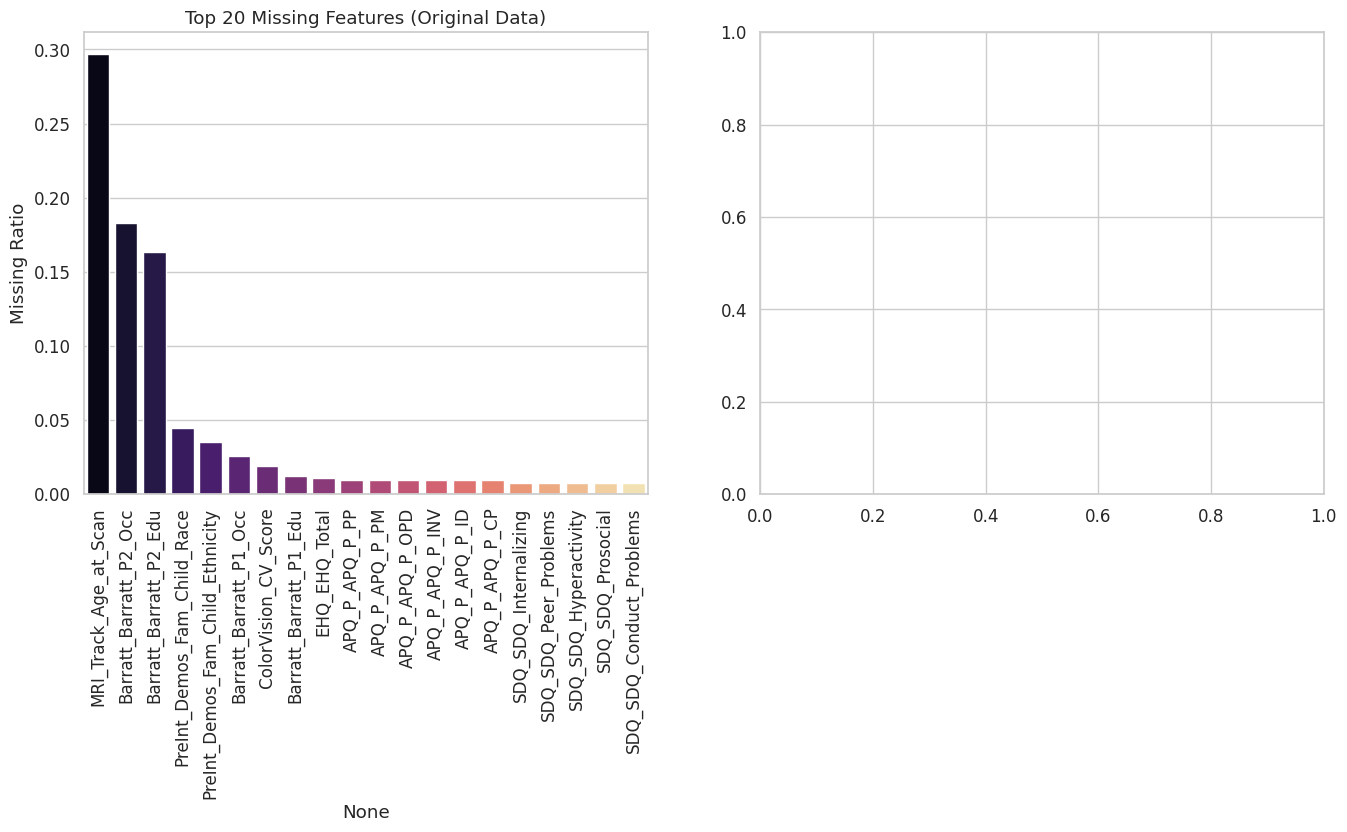

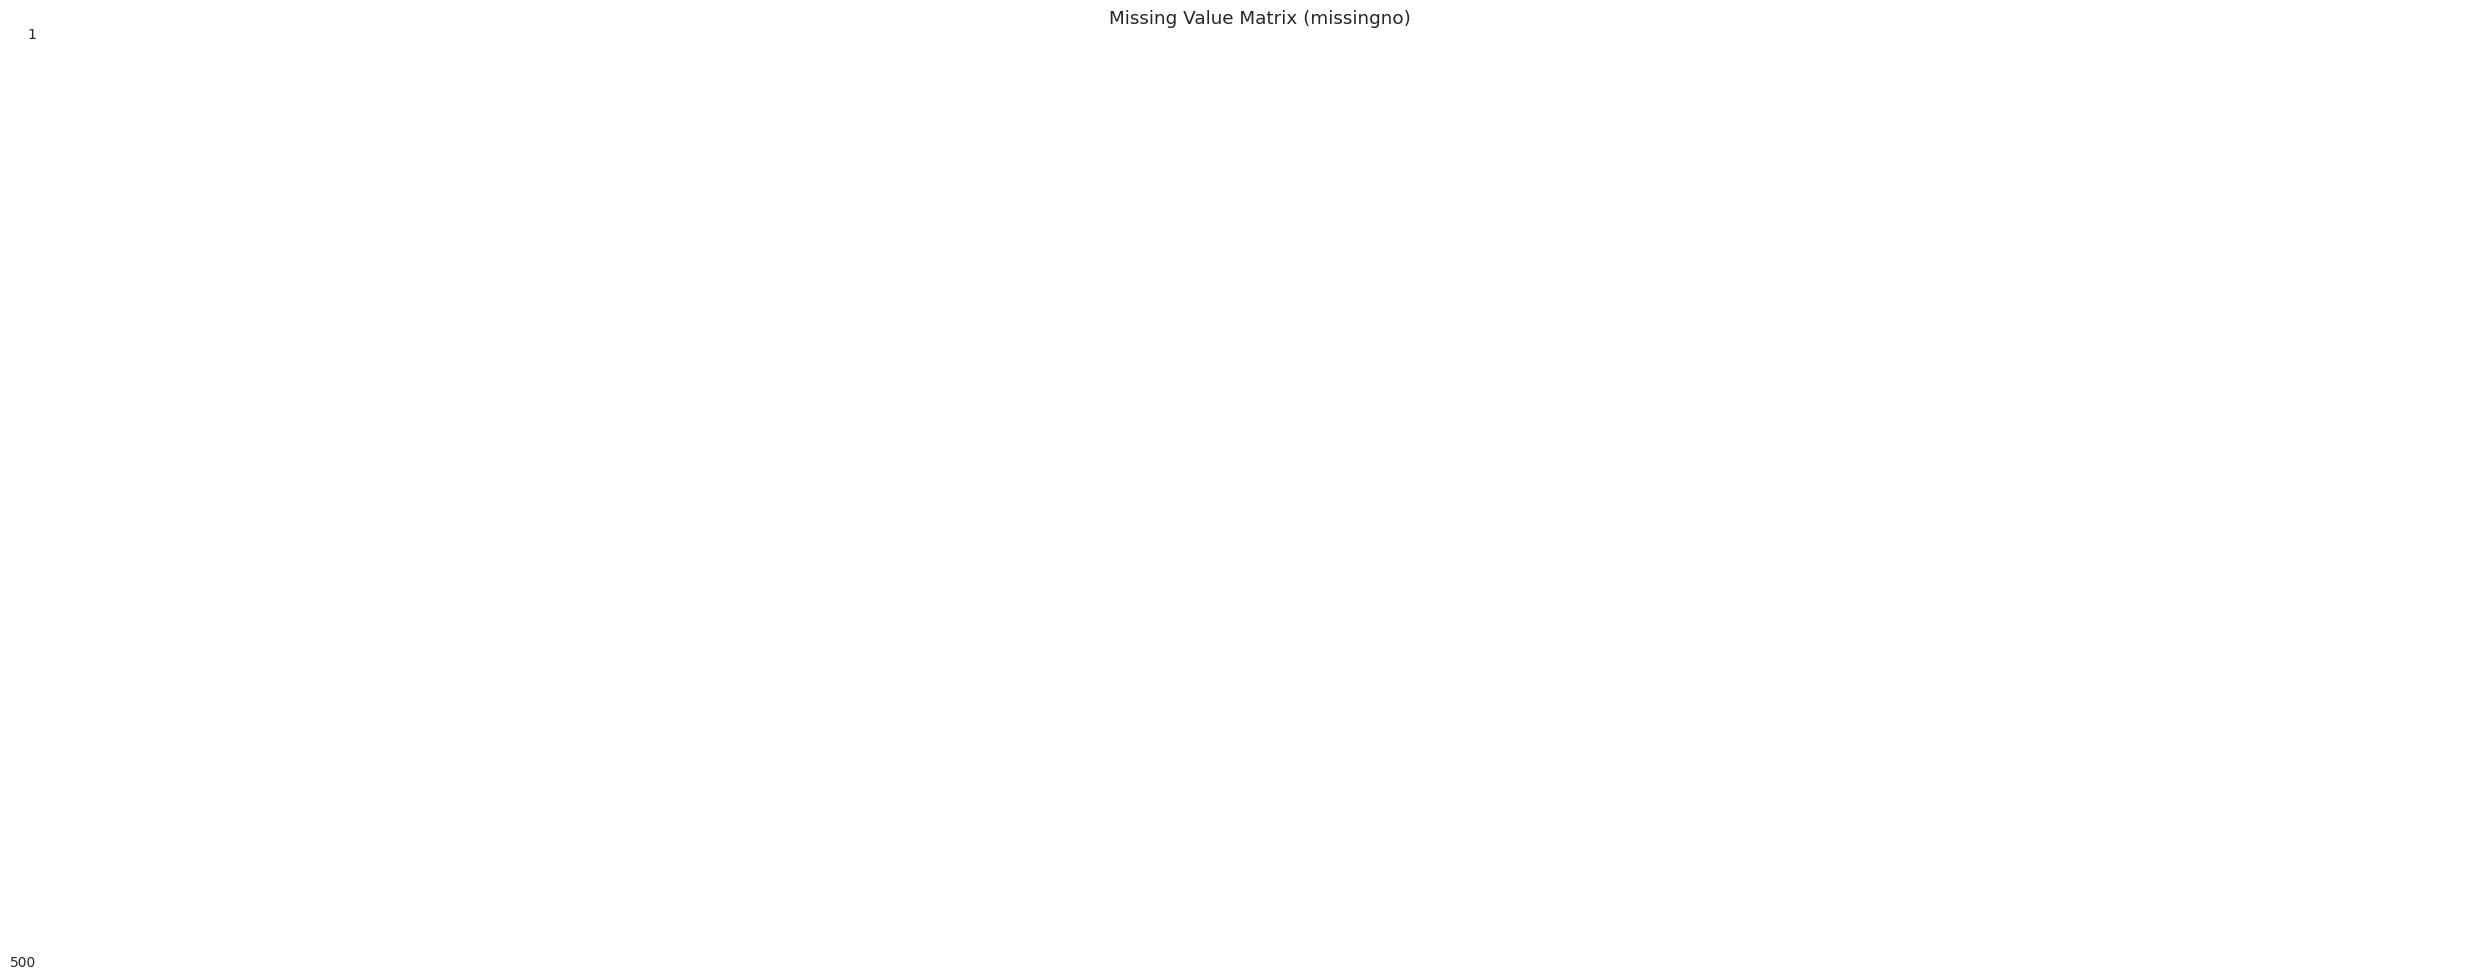

In [17]:
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Load RAW Data for Missing Value Analysis (TRAIN_NEW only)
# ------------------------------------------------------------------------------
print("Loading Raw Data from widsdatathon2025 (TRAIN_NEW)...")

# STRICTLY LIMIT to TRAIN_NEW folder as requested
raw_train_new_dir = os.path.join(RAW_DIR, "TRAIN_NEW")

if os.path.exists(raw_train_new_dir):
    raw_files_pattern = os.path.join(raw_train_new_dir, "TRAIN_*.xlsx")
    raw_csv_pattern = os.path.join(raw_train_new_dir, "TRAIN_*.csv")

    raw_files = glob.glob(raw_files_pattern) + glob.glob(raw_csv_pattern)
    print(f"Searching in: {raw_train_new_dir}")
else:
    print(f"Warning: Directory {raw_train_new_dir} not found. Searching recursively in RAW_DIR for TRAIN_NEW...")
    raw_files = glob.glob(os.path.join(RAW_DIR, "**", "TRAIN_NEW", "TRAIN_*.xlsx"), recursive=True) + \
                glob.glob(os.path.join(RAW_DIR, "**", "TRAIN_NEW", "TRAIN_*.csv"), recursive=True)

# Filter to keep only likely primary files (ignore temp or macos files)
# And ensure they are TRAIN files
raw_files = [f for f in raw_files if "~$" not in f and "MACOSX" not in f and "TRAIN" in os.path.basename(f)]

# We want to merge them to check missingness globally
dfs_raw_list = []

for fpath in raw_files:
    fname = os.path.basename(fpath)
    # We skip TRAINING_SOLUTIONS for missing analysis as it's the target
    if "SOLUTIONS" in fname:
        continue

    print(f"Reading Raw: {fname} ...", end=" ")
    try:
        if fpath.endswith('.xlsx'):
            df_r = pd.read_excel(fpath)
        else:
            df_r = pd.read_csv(fpath)

        # Check if participant_id exists (key for merging)
        if 'participant_id' in df_r.columns:
            dfs_raw_list.append(df_r)
            print(f"OK ({df_r.shape})")
        else:
            print("Skipped (No participant_id)")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

# Merge Raw Data
if dfs_raw_list:
    df_raw = reduce(lambda left, right: pd.merge(left, right, on='participant_id', how='outer'), dfs_raw_list)
    print(f"\nRaw Data Merged. Shape: {df_raw.shape}")

    # --- Analysis ---
    print("\n--- Top 20 Columns with Missing Values (Raw Data) ---")
    missing_raw = df_raw.isnull().sum()
    missing_raw_stats = pd.DataFrame({
        'Missing Count': missing_raw,
        'Missing Ratio': missing_raw / len(df_raw)
    }).sort_values('Missing Ratio', ascending=False)

    display(missing_raw_stats.head(20))

    # Plot
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.barplot(x=missing_raw_stats.head(20).index, y='Missing Ratio', hue=missing_raw_stats.head(20).index, data=missing_raw_stats.head(20), palette="magma", legend=False)
    plt.xticks(rotation=90)
    plt.title("Top 20 Missing Features (Original Data)")

    plt.subplot(1, 2, 2)

    # Robust Missing Value Visualization with Fallback
    try:
        # Attempt to import right before use to ensure it's picked up after install
        import missingno as msno
        msno.matrix(df_raw.sample(min(500, len(df_raw))), sparkline=False, fontsize=8)
        plt.title("Missing Value Matrix (missingno)")
    except ImportError:
        # Fallback to Seaborn Heatmap if missingno fails
        print("Note: missingno library not detected. Using Seaborn heatmap as fallback.")
        sns.heatmap(df_raw.sample(min(500, len(df_raw))).isnull(), cbar=False, yticklabels=False, cmap='viridis')
        plt.title("Missing Value Matrix (Seaborn Fallback)")

    plt.tight_layout()
    plt.show()
else:
    print("Could not load raw data for missing value analysis.")

## 4. Target Analysis
Distribution of ADHD Outcome and Sex.

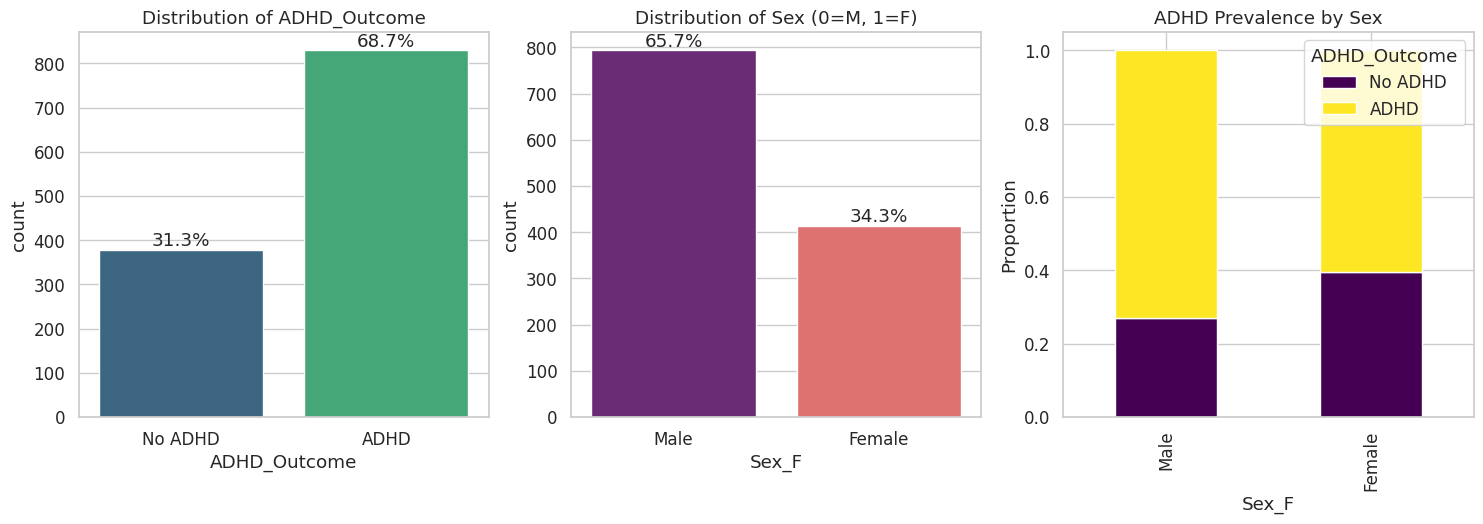

In [18]:
if df_clean is not None:
    df_target = df_clean  # Alias for clarity
    total = len(df_target)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. ADHD Outcome
    if 'ADHD_Outcome' in df_target.columns:
        sns.countplot(
            x='ADHD_Outcome',
            hue='ADHD_Outcome',
            data=df_target,
            ax=axes[0],
            palette='viridis',
            legend=False
        )
        axes[0].set_title('Distribution of ADHD_Outcome')

        # Set ticks before labels to avoid warnings
        axes[0].set_xticks([0, 1])
        axes[0].set_xticklabels(['No ADHD', 'ADHD'])

        for p in axes[0].patches:
            if p.get_height() > 0:
                percentage = '{:.1f}%'.format(100 * p.get_height() / total)
                axes[0].annotate(
                    percentage,
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center',
                    va='bottom'
                )
    else:
        axes[0].text(0.5, 0.5, "ADHD_Outcome column not found", ha='center')

    # 2. Sex Distribution
    if 'Sex_F' in df_target.columns:
        sns.countplot(
            x='Sex_F',
            hue='Sex_F',
            data=df_target,
            ax=axes[1],
            palette='magma',
            legend=False
        )
        axes[1].set_title('Distribution of Sex (0=M, 1=F)')

        axes[1].set_xticks([0, 1])
        axes[1].set_xticklabels(['Male', 'Female'])

        for p in axes[1].patches:
            if p.get_height() > 0:
                percentage = '{:.1f}%'.format(100 * p.get_height() / total)
                axes[1].annotate(
                    percentage,
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center',
                    va='bottom'
                )
    else:
        axes[1].text(0.5, 0.5, "Sex_F column not found", ha='center')

    # 3. ADHD by Sex
    if 'Sex_F' in df_target.columns and 'ADHD_Outcome' in df_target.columns:
        cross_tab = pd.crosstab(
            df_target['Sex_F'],
            df_target['ADHD_Outcome'],
            normalize='index'
        )

        # Plot directly on axes[2]
        cross_tab.plot(
            kind='bar',
            stacked=True,
            ax=axes[2],
            colormap='viridis'
        )

        axes[2].set_title('ADHD Prevalence by Sex')
        axes[2].set_ylabel('Proportion')

        axes[2].set_xticks([0, 1])
        axes[2].set_xticklabels(['Male', 'Female'])

        axes[2].legend(
            title='ADHD_Outcome',
            loc='upper right',
            labels=['No ADHD', 'ADHD']
        )


## 5. Feature EDA: Demographics & Quantitative
Analysis of key demographic and behavioral features.

Main Numeric Features: 56

--- Numeric Summary Statistics (Key Features) ---


,Mean,Std,Median,Min,Max,IQR,CV,Distinct Values
Variable,,,,,,,,
MRI_Track_Age_at_Scan,11.107696,2.724580,10.660049,0.0,21.564453,2.365846,0.245288,839
EHQ_EHQ_Total,59.700108,49.488407,77.800000,-100.0,100.000000,46.685000,0.828950,158
APQ_P_APQ_P_CP,3.812914,1.328335,3.000000,2.0,12.000000,1.000000,0.348378,10
APQ_P_APQ_P_ID,13.338576,3.577352,13.000000,5.0,28.000000,5.000000,0.268196,21
APQ_P_APQ_P_INV,39.766556,4.857042,40.000000,23.0,50.000000,7.000000,0.122139,26
APQ_P_APQ_P_OPD,17.958609,3.319737,18.000000,7.0,28.000000,4.000000,0.184855,21
APQ_P_APQ_P_PM,16.534768,5.122407,16.000000,5.0,37.000000,6.000000,0.309796,30
APQ_P_APQ_P_PP,25.502483,3.041687,26.000000,13.0,30.000000,5.000000,0.119270,18
SDQ_SDQ_Conduct_Problems,2.072434,2.020178,2.000000,0.0,10.000000,3.000000,0.974785,12


/tmp/ipython-input-1668958508.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CV', y=summary_sorted.index, data=summary_sorted, palette='crest') # Changed to crest to match Section 6


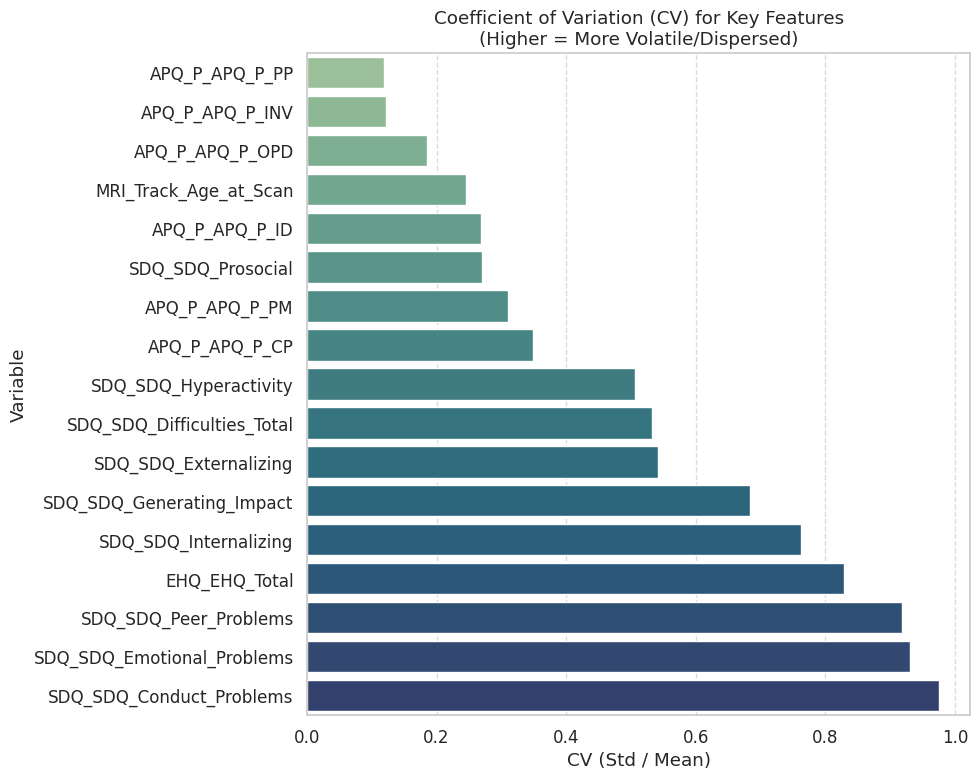


Checking potential outliers/ranges for specific features:

EHQ_EHQ_Total (Min: -100.00, Max: 100.00, Median: 77.80)

MRI_Track_Age_at_Scan (Min: 0.00, Max: 21.56, Median: 10.66)

--- Key Feature Distributions ---


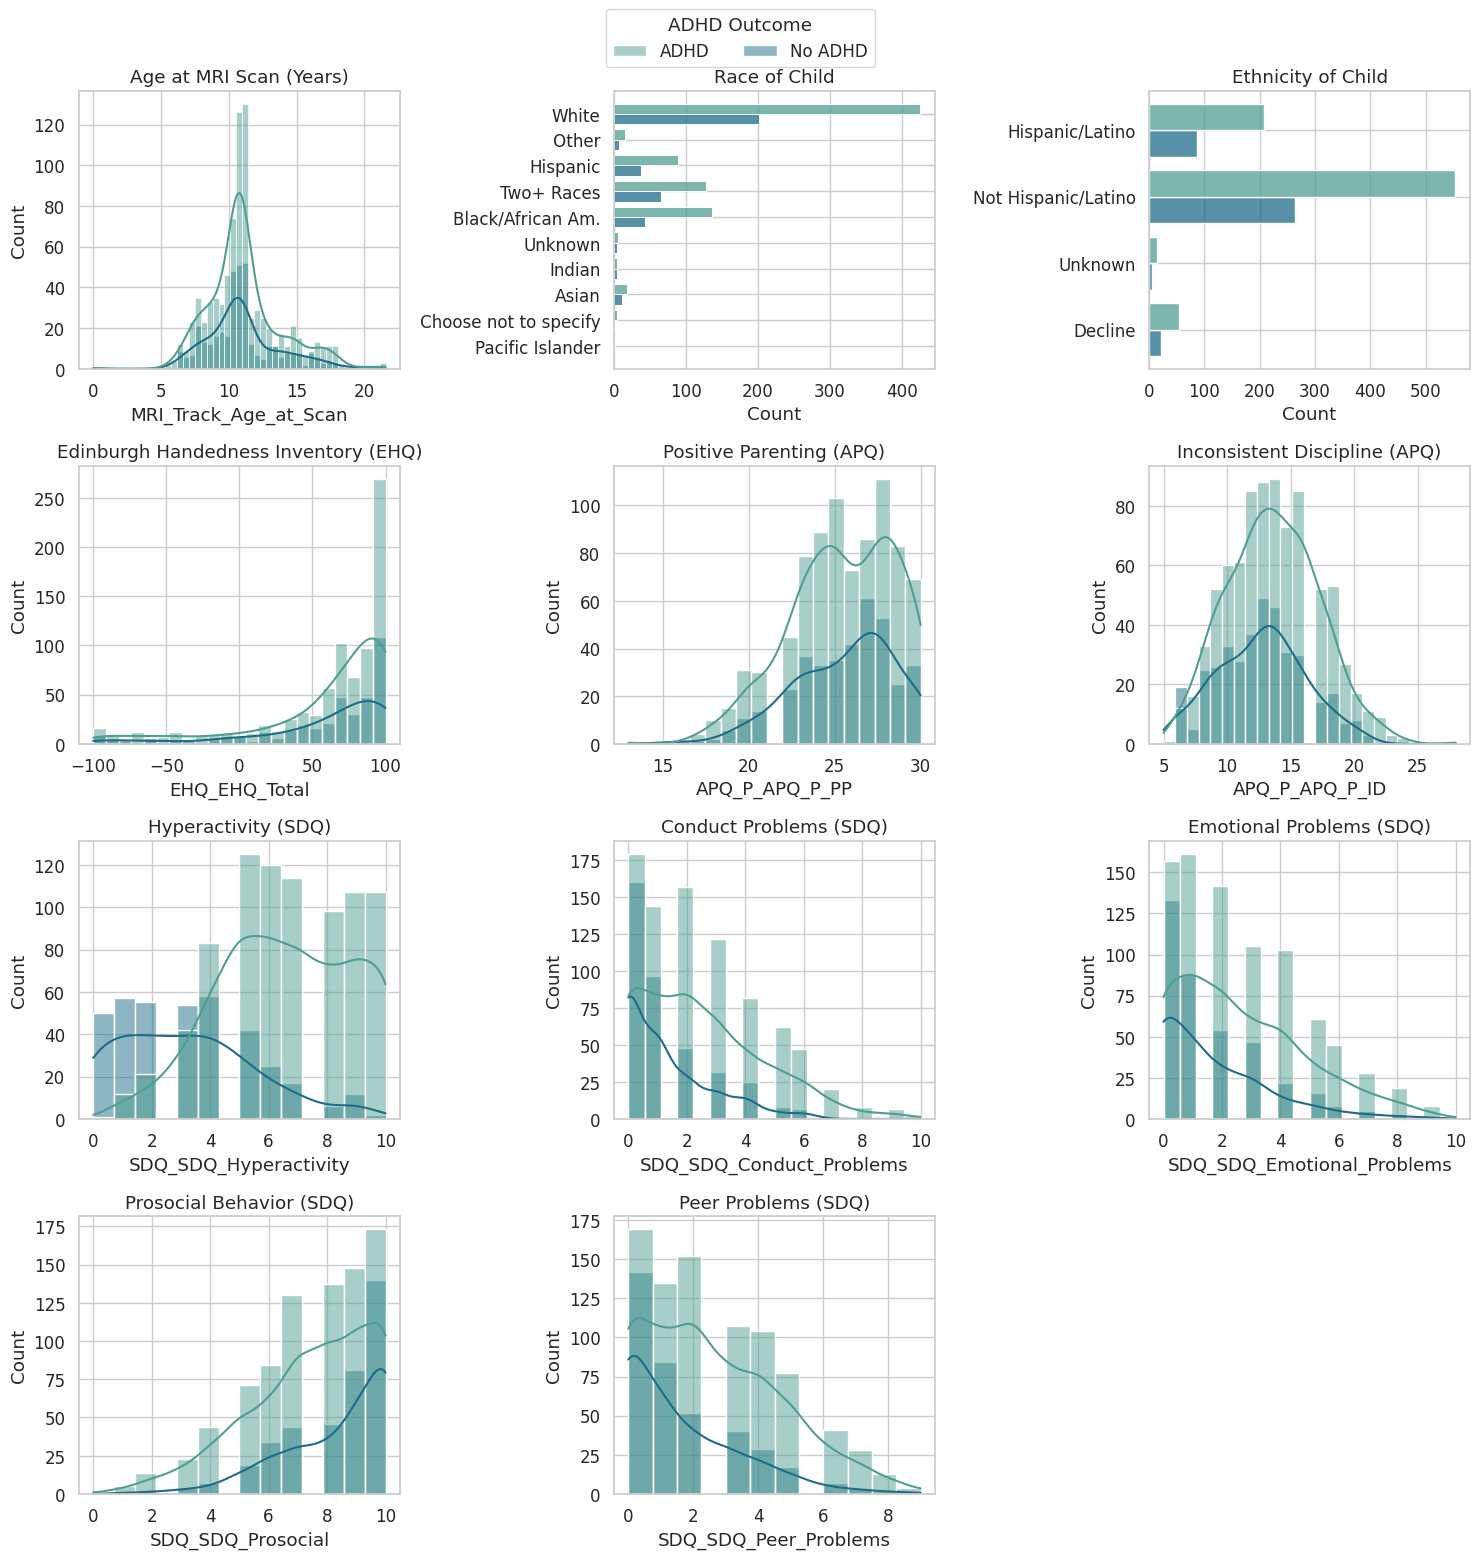


--- Correlation Analysis ---


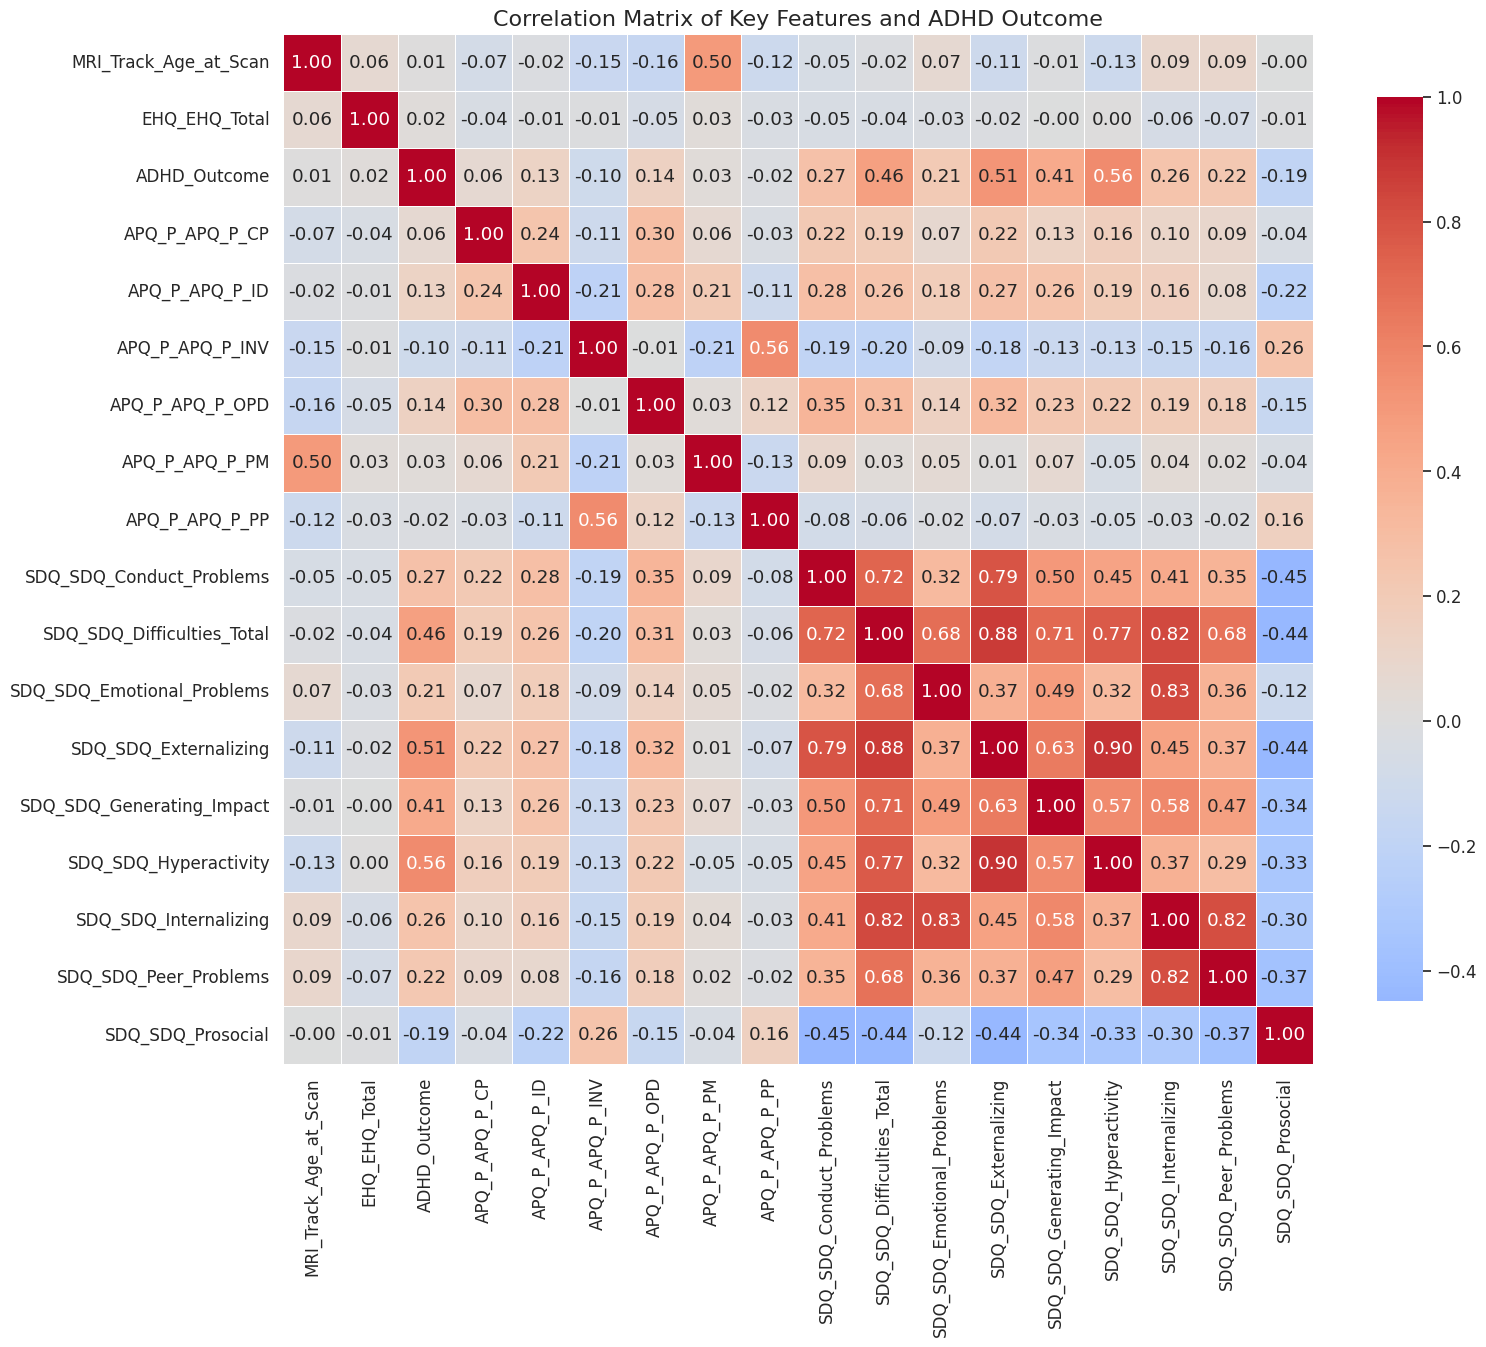

/tmp/ipython-input-1668958508.py:307: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette=colors)


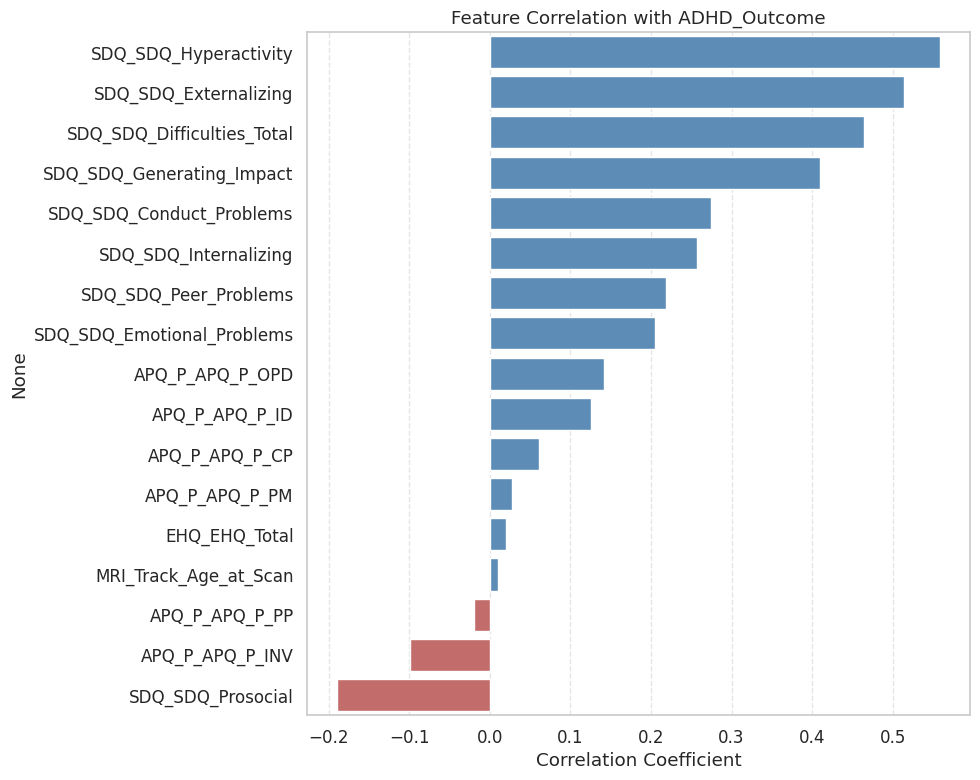

In [19]:
if df_clean is not None:
    # Identify columns
    id_col = 'participant_id'
    target_cols = ['ADHD_Outcome', 'Sex_F']
    numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

    # Exclude IDs, Targets, and FCM columns for cleaner univariate plots
    main_numeric = [c for c in numeric_features
                   if c not in target_cols
                   and not c.startswith('fcm_')
                   and not c.startswith('0throw')
                   and 'throw' not in c
                   and 'column' not in c]

    print(f"Main Numeric Features: {len(main_numeric)}")

    # ------------------------------------------------------------------------------
    # 5.1 Numeric Summary Statistics (Key 18 Features)
    # ------------------------------------------------------------------------------
    # Define key numeric variables for detailed summary
    # Include missing indicator columns as requested for CV Analysis
    key_numeric = ['MRI_Track_Age_at_Scan', 'EHQ_EHQ_Total', 'ColorVision_cv_Score']
    # Exclude missing indicators as per user request ("don't want those missing data")
    key_numeric += [c for c in df_clean.columns if c.startswith('APQ_P_') and not c.endswith('__missing_ind')]
    key_numeric += [c for c in df_clean.columns if c.startswith('SDQ_SDQ_') and not c.endswith('__missing_ind')]

    # Filter existing columns only
    key_numeric = [c for c in key_numeric if c in df_clean.columns]

    if key_numeric:
        print("\n--- Numeric Summary Statistics (Key Features) ---")
        stats_list = []
        for col in key_numeric:
            s = df_clean[col]
            stats_list.append({
                'Variable': col,
                'Mean': s.mean(),
                'Std': s.std(),
                'Median': s.median(),
                'Min': s.min(),
                'Max': s.max(),
                'IQR': s.quantile(0.75) - s.quantile(0.25),
                'CV': s.std() / s.mean() if s.mean() != 0 else np.nan,
                'Distinct Values': s.nunique()
            })

        summary_df = pd.DataFrame(stats_list).set_index('Variable')
        display(summary_df)

        # --- VISUALIZATION FOR NUMERIC SUMMARY (CV Comparison) ---
        plt.figure(figsize=(10, 8))
        # Sort by CV for better visualization (Descending)
        summary_sorted = summary_df.sort_values('CV', ascending=False) # Changed to False to match typical high-to-low importance
        # Actually image shows ascending or descending? Image 1 shows ascending from top (low CV) to bottom (high CV)?
        # Wait, the image provided shows bars growing from left to right.
        # Top bar: APQ_P_APQ_P_PP (short)
        # Bottom bar: SDQ_SDQ_Conduct_Problems (long)
        # So it is sorted by CV ascending (Smallest at top, Largest at bottom).
        summary_sorted = summary_df.sort_values('CV', ascending=True)

        sns.barplot(x='CV', y=summary_sorted.index, data=summary_sorted, palette='crest') # Changed to crest to match Section 6
        plt.title('Coefficient of Variation (CV) for Key Features\n(Higher = More Volatile/Dispersed)')
        plt.xlabel('CV (Std / Mean)')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Check for potential outliers in specific columns
        check_cols = ['EHQ_EHQ_Total', 'ColorVision_cv_Score', 'MRI_Track_Age_at_Scan']
        print("\nChecking potential outliers/ranges for specific features:")
        for c in check_cols:
            if c in df_clean.columns:
                desc = df_clean[c].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
                print(f"\n{c} (Min: {desc['min']:.2f}, Max: {desc['max']:.2f}, Median: {desc['50%']:.2f})")

    if df_clean is not None:
        print("\n--- Key Feature Distributions ---")

        # Set style to match user preference (Whitegrid)
        sns.set_style("whitegrid")

        # Explicitly select meaningful features for visualization (Top 9)
        # Matching Image 2 Grid Layout
        # Row 1: Age, Race, Ethnicity
        # Row 2: EHQ, APQ_PP, APQ_ID
        # Row 3: SDQ_Hyper, SDQ_Conduct, SDQ_Emotional
        # Row 4: SDQ_Prosocial, SDQ_Peer
        selected_features = [
            'MRI_Track_Age_at_Scan',             # Age (Continuous)
            'PreInt_Demos_Fam_Child_Race',       # Race (Categorical)
            'PreInt_Demos_Fam_Child_Ethnicity',  # Ethnicity (Categorical)
            'EHQ_EHQ_Total',                     # Handedness Score (Continuous)
            'APQ_P_APQ_P_PP',                    # APQ: Positive Parenting (Score)
            'APQ_P_APQ_P_ID',                    # APQ: Inconsistent Discipline (Score)
            'SDQ_SDQ_Hyperactivity',             # SDQ: Hyperactivity (Score)
            'SDQ_SDQ_Conduct_Problems',          # SDQ: Conduct Problems (Score)
            'SDQ_SDQ_Emotional_Problems',        # SDQ: Emotional Problems (Score)
            'SDQ_SDQ_Prosocial',                 # SDQ: Prosocial (Score)
            'SDQ_SDQ_Peer_Problems'              # SDQ: Peer Problems (Score)
        ]

        # Filter to only those present in df
        missing_features = [c for c in selected_features if c not in df_clean.columns]
        if missing_features:
            print(f"Warning: The following requested features are missing from the dataframe: {missing_features}")
            print("Please check if the 'cleaned_train_categorical.csv' file was loaded correctly.")

        selected_features = [c for c in selected_features if c in df_clean.columns]

        # Define mappings for categorical variables
        categorical_mappings = {
            'PreInt_Demos_Fam_Child_Ethnicity': {
                0: 'Not Hispanic/Latino', 1: 'Hispanic/Latino', 2: 'Decline', 3: 'Unknown'
            },
            'PreInt_Demos_Fam_Child_Race': {
                0: 'White', 1: 'Black/African Am.', 2: 'Hispanic', 3: 'Asian', 4: 'Indian',
                5: 'Native Am.', 6: 'Am. Indian/Alaskan', 7: 'Pacific Islander',
                8: 'Two+ Races', 9: 'Other', 10: 'Unknown', 11: 'Choose not to specify'
            },
            'Sex_F': {0: 'Male', 1: 'Female'}
        }

        # Plotting
        n_plot = len(selected_features)
        rows = (n_plot - 1) // 3 + 1

        # Helper to get descriptive title
        def get_clean_title(col_name):
            title_map = {
                'MRI_Track_Age_at_Scan': 'Age at MRI Scan (Years)',
                'EHQ_EHQ_Total': 'Edinburgh Handedness Inventory (EHQ)',
                'ColorVision_cv_Score': 'Color Vision Score',
                'ADHD_Outcome': 'ADHD Diagnosis (Target)',
                'Sex_F': 'Biological Sex',
                'PreInt_Demos_Fam_Child_Race': 'Race of Child',
                'PreInt_Demos_Fam_Child_Ethnicity': 'Ethnicity of Child',
                'APQ_P_APQ_P_PP': 'Positive Parenting (APQ)',
                'APQ_P_APQ_P_ID': 'Inconsistent Discipline (APQ)',
                'SDQ_SDQ_Hyperactivity': 'Hyperactivity (SDQ)',
                'SDQ_SDQ_Conduct_Problems': 'Conduct Problems (SDQ)',
                'SDQ_SDQ_Emotional_Problems': 'Emotional Problems (SDQ)',
                'SDQ_SDQ_Prosocial': 'Prosocial Behavior (SDQ)',
                'SDQ_SDQ_Peer_Problems': 'Peer Problems (SDQ)'
            }
            if col_name in title_map:
                return title_map[col_name]
            return col_name

        # Prepare for Plotting with Hue
        # Ensure ADHD_Outcome is mapped for legend if needed, or use numeric 0/1 with legend override
        plot_df = df_clean.copy()
        if 'ADHD_Outcome' in plot_df.columns:
            # Map for better legend
            plot_df['ADHD_Label'] = plot_df['ADHD_Outcome'].map({0: 'No ADHD', 1: 'ADHD'})
        else:
            plot_df['ADHD_Label'] = 'Unknown'

        fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
        axes = axes.flatten()

        # Legend handling: Get handles from one plot and add global legend?
        # Or just let seaborn handle it per plot (can be messy).
        # Image 2 shows a common legend at top. We'll try to replicate.

        global_handles = None
        global_labels = None

        for i, col in enumerate(selected_features):
            ax = axes[i]

            # Check if this column needs mapping (is categorical)
            if col in categorical_mappings:
                # Use histplot with discrete=True to match the style of other plots (bars)
                # We map the column in plot_df temporarily for display
                plot_df[f'{col}_mapped'] = plot_df[col].map(categorical_mappings[col])

                sns.histplot(
                    y=f'{col}_mapped',
                    data=plot_df,
                    hue='ADHD_Label',
                    ax=ax,
                    palette='crest',
                    multiple="dodge", # Side-by-side bars for categorical
                    element="bars",   # Solid bars
                    shrink=0.8,       # Spacing between bars
                    edgecolor='white' # Explicit separation
                )
                ax.set_title(get_clean_title(col))
                ax.set_xlabel("Count")
                ax.set_ylabel("")

                # Capture legend handles from the first plot before removing
                if i == 0 and ax.legend_:
                    # Histplot creates a legend object differently
                    global_handles = ax.legend_.legend_handles
                    global_labels = [t.get_text() for t in ax.legend_.texts]

                if ax.legend_:
                    ax.legend_.remove() # Remove individual legends to avoid clutter
            else:
                # Standard numeric histogram with KDE and Hue
                sns.histplot(
                    data=plot_df,
                    x=col,
                    hue='ADHD_Label',
                    kde=True,
                    ax=ax,
                    palette='crest',
                    element="bars",   # Solid bars
                    edgecolor='white', # Explicit separation
                    common_norm=False
                )
                ax.set_title(get_clean_title(col))
                ax.set_xlabel(col)

                # Capture legend handles from the first plot before removing
                if i == 0 and ax.legend_:
                    # Seaborn histplot legend handling can be tricky, let's try standard matplotlib way
                    global_handles, global_labels = ax.get_legend_handles_labels()
                    # If empty (sometimes happens with seaborn objects), try accessing legend_ directly
                    if not global_handles and ax.legend_:
                         global_handles = ax.legend_.legend_handles
                         global_labels = [t.get_text() for t in ax.legend_.texts]

                if ax.legend_:
                    ax.legend_.remove()

        for j in range(i+1, len(axes)):
            axes[j].axis('off')

        # Add Global Legend
        if global_handles:
            fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, title="ADHD Outcome")

        # Adjust layout to make room for legend
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ------------------------------------------------------------------------------
    # Correlation Analysis (Appended)
    # ------------------------------------------------------------------------------
    if df_clean is not None:
        print("\n--- Correlation Analysis ---")

        # Select columns for correlation analysis (Matching Image 3 List)
        target_col = 'ADHD_Outcome'

        # Exact list from Image 3
        corr_cols_ordered = [
            'MRI_Track_Age_at_Scan',
            'EHQ_EHQ_Total',
            'ADHD_Outcome',
            'APQ_P_APQ_P_CP',
            'APQ_P_APQ_P_ID',
            'APQ_P_APQ_P_INV',
            'APQ_P_APQ_P_OPD',
            'APQ_P_APQ_P_PM',
            'APQ_P_APQ_P_PP',
            'SDQ_SDQ_Conduct_Problems',
            'SDQ_SDQ_Difficulties_Total',
            'SDQ_SDQ_Emotional_Problems',
            'SDQ_SDQ_Externalizing',
            'SDQ_SDQ_Generating_Impact',
            'SDQ_SDQ_Hyperactivity',
            'SDQ_SDQ_Internalizing',
            'SDQ_SDQ_Peer_Problems',
            'SDQ_SDQ_Prosocial'
        ]

        # Filter to ensure columns exist in the dataframe
        corr_cols = [c for c in corr_cols_ordered if c in df_clean.columns]

        # Calculate Correlation Matrix
        corr_matrix = df_clean[corr_cols].corr()

        # 1. Heatmap (All vs All)
        plt.figure(figsize=(16, 14))
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
        )
        plt.title('Correlation Matrix of Key Features and ADHD Outcome', fontsize=16)
        plt.tight_layout()
        plt.show()

        # 2. Bar Chart (Feature Correlation with ADHD_Outcome)
        # Added as per user request to show correlation with target
        plt.figure(figsize=(10, 8))

        # Get correlations with target
        if 'ADHD_Outcome' in corr_matrix.columns:
            target_corr = corr_matrix['ADHD_Outcome'].drop('ADHD_Outcome')

            # Sort by correlation strength (Descending: Highest Positive at Top)
            target_corr_sorted = target_corr.sort_values(ascending=False)

            # Create colors based on sign (Positive=Blue, Negative=Red)
            # Using specific hex codes to match typical styles or simple conditional
            colors = ['#4e8ec6' if x >= 0 else '#d15e5e' for x in target_corr_sorted.values]

            sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette=colors)

            plt.title('Feature Correlation with ADHD_Outcome')
            plt.xlabel('Correlation Coefficient')
            plt.ylabel('None') # Matches user provided image label
            plt.grid(axis='x', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()


## 6. Functional Connectivity Analysis (MRI)
Analysis of fMRI connectivity matrices and ROI mapping.


--- Functional Connectivity Analysis ---
Reloading original connectome data for accurate ROI mapping...
Found connectome file: /content/drive/MyDrive/cleaned_data/cleaned_train_connectome.csv
Merged for analysis. Shape: (1208, 19903)
Number of Functional Connectivity features found: 2080


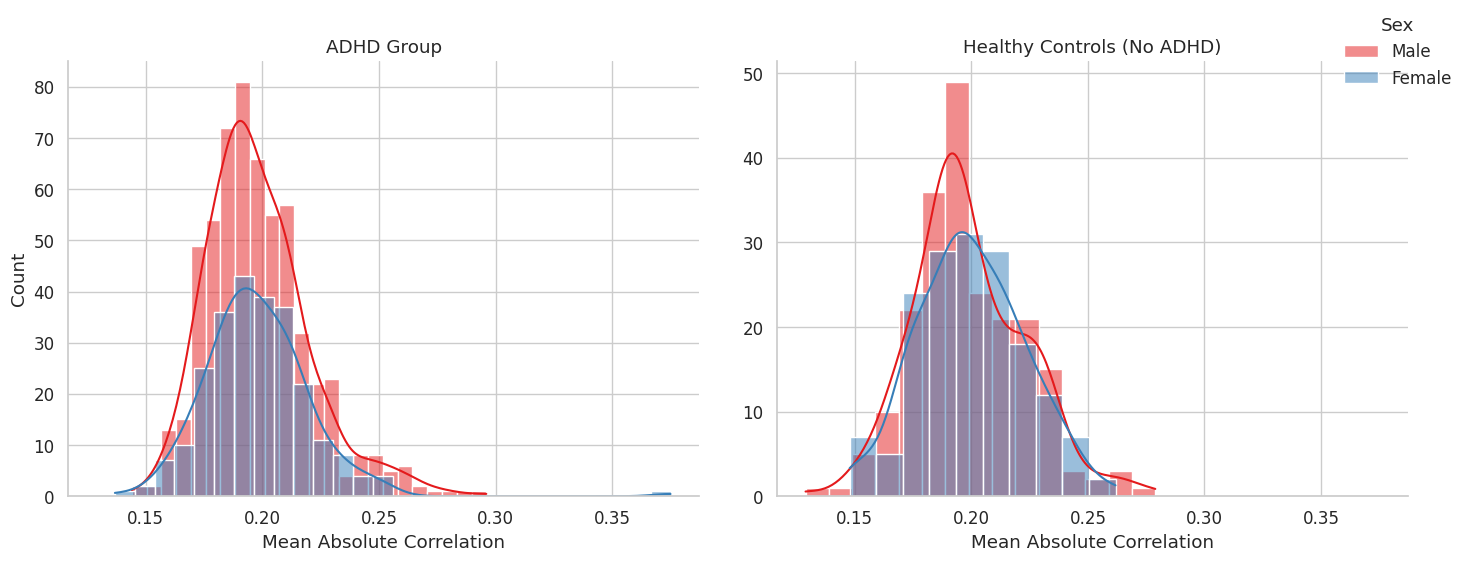

Calculating correlations with ADHD_Outcome for all edges... (this may take a moment)
Successfully loaded ROI labels from: /content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv

--- Top Functional Connectivity Features (Biological Interpretation) ---


,Type,Correlation,Network A,ROI A,Network B,ROI B,Feature
0,Risk (Positive),0.0941,control B,17Networks_LH_ContB_PFClv_2,default A,17Networks_RH_DefaultA_PFCm_1,70throw_186thcolumn
1,Risk (Positive),0.0939,central visual,17Networks_LH_VisCent_ExStr_1,central visual,17Networks_RH_VisCent_Striate_1,0throw_102thcolumn
2,Risk (Positive),0.0929,central visual,17Networks_LH_VisCent_ExStr_1,central visual,17Networks_RH_VisCent_ExStr_3,0throw_103thcolumn
3,Risk (Positive),0.0900,control B,17Networks_LH_ContB_PFClv_2,default A,17Networks_LH_DefaultA_PFCm_3,70throw_81thcolumn
4,Risk (Positive),0.0839,dorsal attention A,17Networks_RH_DorsAttnA_TempOcc_1,limbic B,17Networks_RH_LimbicB_OFC_4,130throw_159thcolumn
5,Risk (Positive),0.0838,control A,17Networks_LH_ContA_PFCd_1,default A,17Networks_LH_DefaultA_PFCd_1,60throw_75thcolumn
6,Risk (Positive),0.0823,control A,17Networks_LH_ContA_PFCd_1,default A,17Networks_RH_DefaultA_PFCd_1,60throw_184thcolumn
7,Risk (Positive),0.0821,control B,17Networks_LH_ContB_PFClv_2,control C,17Networks_RH_ContC_pCun_1,70throw_180thcolumn
8,Risk (Positive),0.0815,control B,17Networks_LH_ContB_PFClv_2,default C,17Networks_RH_DefaultC_Rsp_1,70throw_194thcolumn
9,Risk (Positive),0.0811,default A,17Networks_LH_DefaultA_PFCm_2,central visual,17Networks_RH_VisCent_ExStr_5,80throw_105thcolumn


/tmp/ipython-input-2250863651.py:243: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  sns.barplot(x=df_top_edges['Correlation'], y=labels, hue=df_top_edges.index, palette=colors, legend=False)


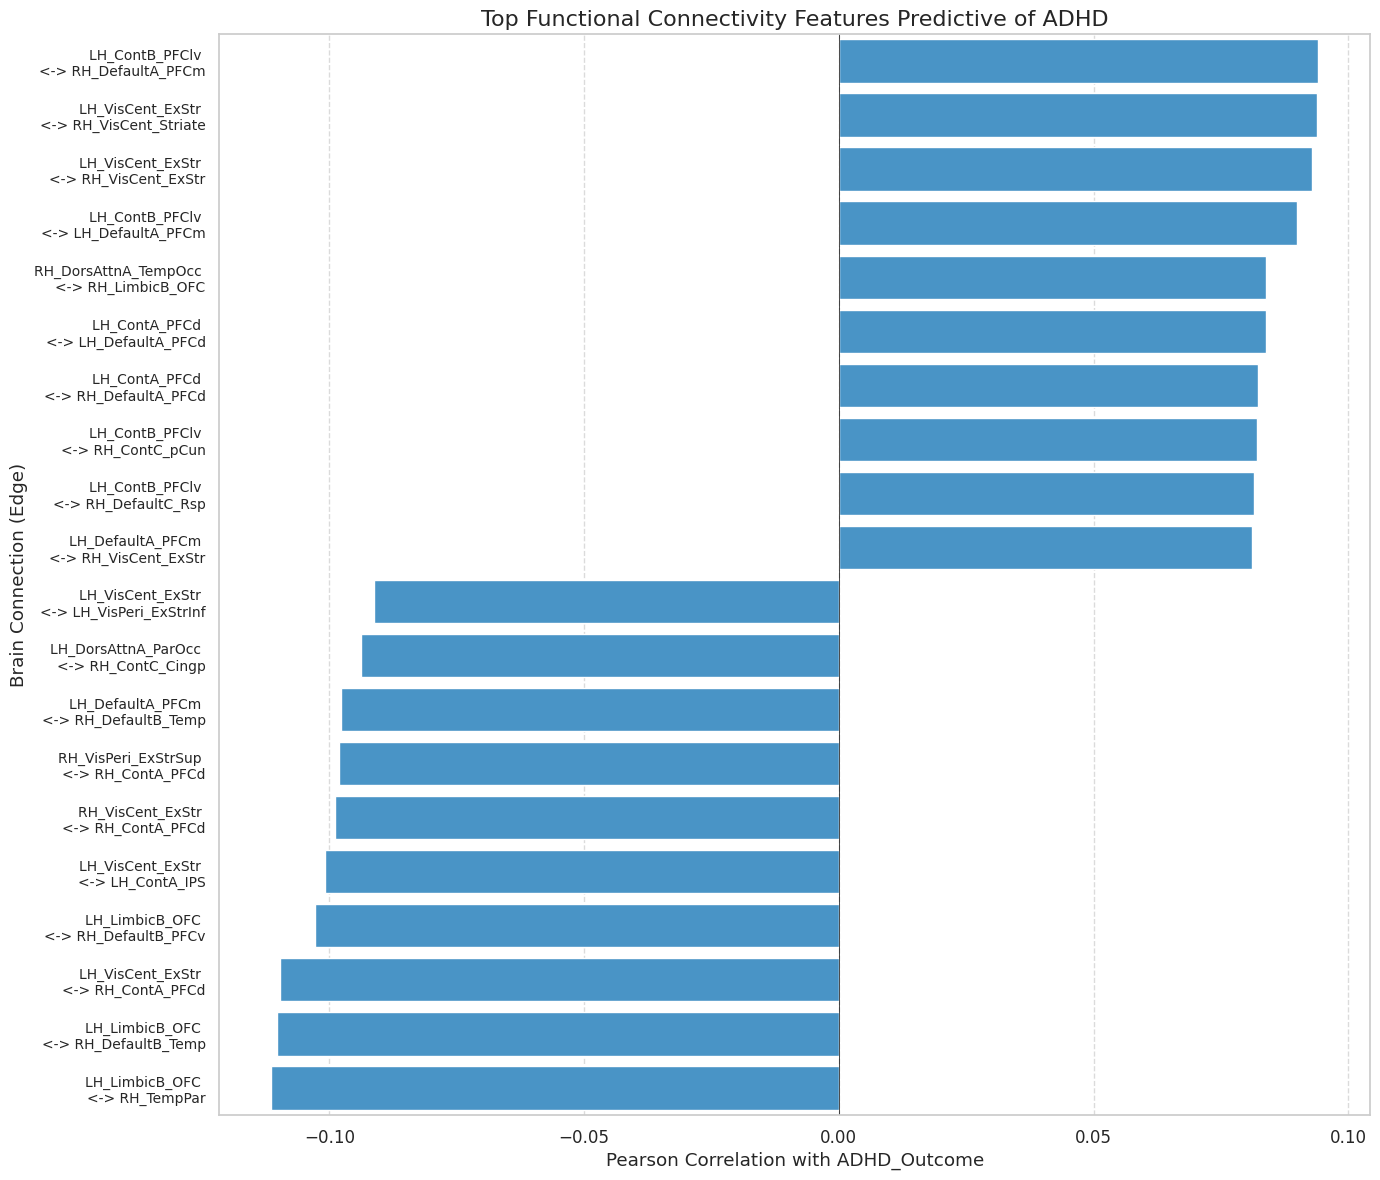

In [21]:
# ------------------------------------------------------------------------------
# 6. Functional Connectivity Analysis (MRI)
# ------------------------------------------------------------------------------
if df_clean is not None:
    print("\n--- Functional Connectivity Analysis ---")

    # RELOAD Connectome Data to get original column names (0throw_...)
    # This avoids the issue where previous steps renamed/corrupted the columns
    print("Reloading original connectome data for accurate ROI mapping...")

    import glob
    import os

    # Try to find the connectome file
    # Common paths in Colab/Local
    possible_dirs = [
        '/content/drive/MyDrive/cleaned_data', # Drive path from screenshot
        'cleaned_data/cleaned_data',
        '/content/cleaned_data/cleaned_data',
        '/content/cleaned_data',
        '/content', # Root of Colab
        r'F:\0Master\project\EDA\cleaned_data\cleaned_data',
        'cleaned_data', # Try direct subfolder
        '.' # Try current directory
    ]

    connectome_path = None
    for d in possible_dirs:
        # Search for *connectome*.csv to be more flexible (cleaned_train_connectome.csv)
        files = glob.glob(os.path.join(d, "*connectome*.csv"))
        if files:
            connectome_path = files[0]
            print(f"Found connectome file: {connectome_path}")
            break

    if connectome_path:
        # Load only connectome data
        df_fcm_raw = pd.read_csv(connectome_path)

        # Merge with Target (ADHD_Outcome, Sex_F) from df_clean
        # We need participant_id for merging
        if 'participant_id' in df_fcm_raw.columns and 'participant_id' in df_clean.columns:
            target_subset = df_clean[['participant_id', 'ADHD_Outcome', 'Sex_F']].drop_duplicates(subset=['participant_id'])
            df_analysis = pd.merge(df_fcm_raw, target_subset, on='participant_id', how='inner')
            print(f"Merged for analysis. Shape: {df_analysis.shape}")

            # Identify FCM columns (now they should be 0throw_...)
            fcm_cols = [c for c in df_analysis.columns if '0throw' in c]
            print(f"Number of Functional Connectivity features found: {len(fcm_cols)}")

            if len(fcm_cols) > 0:
                # 2. Global Connectivity Strength
                df_analysis['Global_Connectivity_Mean'] = df_analysis[fcm_cols].abs().mean(axis=1)

                # Updated Plot: Two subplots separated by ADHD_Outcome
                # Left: Non-ADHD (Healthy), Right: ADHD
                # Both colored by Sex

                # Check if columns exist
                if 'ADHD_Outcome' in df_analysis.columns and 'Sex_F' in df_analysis.columns:
                    # Create mapping for better labels
                    df_analysis['ADHD_Group'] = df_analysis['ADHD_Outcome'].map({0: 'Healthy Controls (No ADHD)', 1: 'ADHD Group'})
                    df_analysis['Sex'] = df_analysis['Sex_F'].map({0: 'Male', 1: 'Female'})

                    # Use FacetGrid for consistent style with Section 5
                    g = sns.FacetGrid(df_analysis,col="ADHD_Group",hue="Sex",height=6,aspect=1.2,palette="Set1",    sharey=False
)

                    g.map(sns.histplot, "Global_Connectivity_Mean", kde=True, element="bars", edgecolor='white', alpha=0.5)

                    # Adjust Titles and Labels
                    g.set_titles("{col_name}")
                    g.set_axis_labels("Mean Absolute Correlation", "Count")

                    # Add Legend
                    g.add_legend(title="Sex", loc='upper right', bbox_to_anchor=(0.95, 0.95))

                    plt.subplots_adjust(top=0.85)
                    plt.show()

                else:
                    print("Required columns (ADHD_Outcome, Sex_F) missing for split visualization.")
                    plt.figure(figsize=(10, 6))
                    sns.histplot(df_analysis['Global_Connectivity_Mean'], kde=True, color='purple')
                    plt.title('Distribution of Global Mean Connectivity Strength')
                    plt.show()

                # 3. Correlation with ADHD Outcome
                if 'ADHD_Outcome' in df_analysis.columns:
                    print("Calculating correlations with ADHD_Outcome for all edges... (this may take a moment)")

                    target = df_analysis['ADHD_Outcome']
                    fcm_data = df_analysis[fcm_cols]

                    # Vectorized correlation
                    fcm_corrs = fcm_data.corrwith(target)

                    # Sort correlations
                    fcm_corrs_sorted = fcm_corrs.sort_values(ascending=False)

                    # Extract Top 10 Positive (Risk) and Negative (Protective)
                    # Ensure we are getting unique values
                    top_positive = fcm_corrs_sorted.head(10)
                    top_negative = fcm_corrs_sorted.tail(10)

                    # --- ENHANCED ROI MAPPING LOGIC ---
                    import re

    # Load ROI labels
            # Updated path based on user feedback (file is in My Drive/cleaned_data)
            possible_paths = [
                '/content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv', # Drive path from screenshot
                'cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                'Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                '/content/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                '/content/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                r'F:\0Master\project\EDA\Schaefer200_merged_labels(Schaefer200_merged_labels).csv'
            ]

            roi_df = None
            for p in possible_paths:
                try:
                    roi_df = pd.read_csv(p)
                    print(f"Successfully loaded ROI labels from: {p}")
                    break
                except:
                    continue

            roi_map = {}
            if roi_df is not None:
                # Map 'ROI Label' (1-based) to 'ROI Name' and 'Network Name'
                for _, row in roi_df.iterrows():
                    # Note: Column names are likely 0-based indices from the raw data generation
                    # But Schaefer labels are 1-based.
                    # Usually python processing results in 0-based indices matching the order.
                    # Let's assume index 0 -> Label 1
                    idx = int(row['ROI Label']) - 1
                    roi_map[idx] = {
                        'Name': row['ROI Name'],
                        'Network': row['Network Name']
                    }
            else:
                print("Warning: Could not load ROI labels from any path. Using raw column names.")

            def parse_column_name(col_name):
                # Format: 0throw_1thcolumn -> ROI 0 and ROI 1
                # Regex to extract numbers from 0throw_ format
                # Handles '0throw_1thcolumn', '0throw_1stcolumn', '0throw_2ndcolumn' etc.
                match = re.search(r'(\d+)throw_(\d+)(?:st|nd|rd|th)column', col_name)
                if match:
                    idx1 = int(match.group(1))
                    idx2 = int(match.group(2))
                    # IMPORTANT: Check if indices are within bounds of roi_map keys
                    # roi_map keys are 0-199 based on our previous logic
                    return idx1, idx2
                return None, None

            def get_edge_info(col_name, corr_val):
                info = {'Feature': col_name, 'Correlation': corr_val}

                # Default values
                info['ROI A'] = 'Unknown'
                info['ROI B'] = 'Unknown'
                info['Network A'] = 'Unknown'
                info['Network B'] = 'Unknown'

                if not roi_map:
                    return info

                idx1, idx2 = parse_column_name(col_name)

                # Debugging helper
                if idx1 is not None:
                    # Try multiple key variations for robustness
                    # 1. Direct match (e.g. key 0)
                    # 2. 1-based match (e.g. key 1)
                    # 3. String match (e.g. key "1")

                    # Lookup A
                    roi_a_data = None
                    if idx1 in roi_map: roi_a_data = roi_map[idx1]
                    elif (idx1 + 1) in roi_map: roi_a_data = roi_map[idx1 + 1]
                    elif str(idx1) in roi_map: roi_a_data = roi_map[str(idx1)]

                    if roi_a_data:
                        info['ROI A'] = roi_a_data['Name']
                        info['Network A'] = roi_a_data['Network']
                    else:
                        info['ROI A'] = f"ROI_{idx1}"

                    # Lookup B
                    roi_b_data = None
                    if idx2 in roi_map: roi_b_data = roi_map[idx2]
                    elif (idx2 + 1) in roi_map: roi_b_data = roi_map[idx2 + 1]
                    elif str(idx2) in roi_map: roi_b_data = roi_map[str(idx2)]

                    if roi_b_data:
                        info['ROI B'] = roi_b_data['Name']
                        info['Network B'] = roi_b_data['Network']
                    else:
                        info['ROI B'] = f"ROI_{idx2}"

                return info

            # Create enhanced DataFrames for display
            pos_list = [get_edge_info(idx, val) for idx, val in top_positive.items()]
            neg_list = [get_edge_info(idx, val) for idx, val in top_negative.items()]

            df_pos = pd.DataFrame(pos_list)
            df_pos['Type'] = 'Risk (Positive)'

            df_neg = pd.DataFrame(neg_list)
            df_neg['Type'] = 'Protective (Negative)'

            # Combine and display
            print("\n--- Top Functional Connectivity Features (Biological Interpretation) ---")
            df_top_edges = pd.concat([df_pos, df_neg])

            # Reorder columns for readability
            cols_order = ['Type', 'Correlation', 'Network A', 'ROI A', 'Network B', 'ROI B', 'Feature']
            df_display = df_top_edges[cols_order]

            # Display with styling (Modified to avoid Styler errors with non-unique indices)
            display(df_display.reset_index(drop=True).style.background_gradient(cmap='coolwarm', subset=['Correlation']).format({'Correlation': '{:.4f}'}))

            # Visualization (Bar Chart)
            # Use ROI names as labels if available
            labels = []
            for i, row in df_top_edges.iterrows():
                if row['ROI A'] != 'Unknown':
                    # Shorten names for plot
                    name_a = row['ROI A'].replace('17Networks_', '').rsplit('_', 1)[0]
                    name_b = row['ROI B'].replace('17Networks_', '').rsplit('_', 1)[0]
                    # Use single line format for better readability
                    labels.append(f"{name_a} \n<-> {name_b}")
                else:
                    labels.append(row['Feature'])

            plt.figure(figsize=(14, 12)) # Increased height for better spacing
            colors = ['#3498db' if x >= 0 else '#e74c3c' for x in df_top_edges['Correlation']]

            # Fix: Pass hue and set legend=False to avoid FutureWarning
            sns.barplot(x=df_top_edges['Correlation'], y=labels, hue=df_top_edges.index, palette=colors, legend=False)
            plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

            # Adjust y-axis labels font size
            plt.yticks(fontsize=10)

            plt.title('Top Functional Connectivity Features Predictive of ADHD', fontsize=16)
            plt.xlabel('Pearson Correlation with ADHD_Outcome')
            plt.ylabel('Brain Connection (Edge)')
            plt.grid(axis='x', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print("ADHD_Outcome column not found. Skipping correlation analysis.")
    else:
        print("Merge failed: 'participant_id' missing in one of the dataframes.")
else:
    print("Could not find original connectome file. Please check paths.")
